In [1]:
!pip install imbalanced-learn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop('customerID', axis=1)

y = df['Churn'].map({'Yes': 1, 'No': 0})
X = df.drop('Churn', axis=1)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_cols = [col for col in X.columns if col not in numerical_cols]

Churn
0    5174
1    1869
Name: count, dtype: int64
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


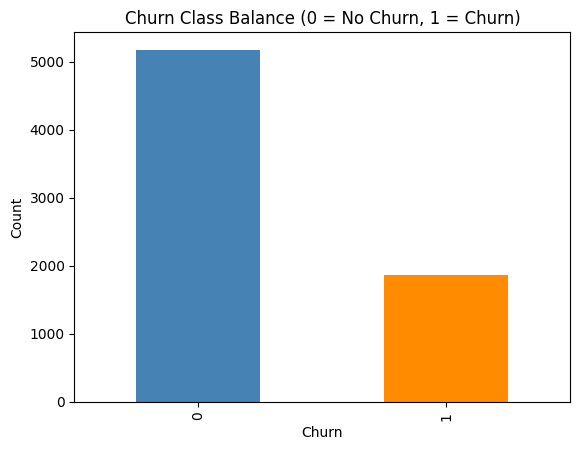

In [2]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

y.value_counts().plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Churn Class Balance (0 = No Churn, 1 = Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.savefig('class_balance.png')
plt.show()

In [3]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline model (bina balancing ke)
baseline_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])
baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

print("=== Baseline (Imbalanced) ===")
print(f"Accuracy: {accuracy_score(y_test, baseline_pred):.2%}")
print(f"Precision: {precision_score(y_test, baseline_pred):.2%}")
print(f"Recall: {recall_score(y_test, baseline_pred):.2%}")
print(f"F1 Score: {f1_score(y_test, baseline_pred):.2%}")

=== Baseline (Imbalanced) ===
Accuracy: 80.55%
Precision: 65.72%
Recall: 55.88%
F1 Score: 60.40%


In [4]:
# class_weight='balanced' use karo — model khud rare class ko zyada weight dega
balanced_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
balanced_pipeline.fit(X_train, y_train)
balanced_pred = balanced_pipeline.predict(X_test)

print("=== Balanced (class_weight='balanced') ===")
print(f"Accuracy: {accuracy_score(y_test, balanced_pred):.2%}")
print(f"Precision: {precision_score(y_test, balanced_pred):.2%}")
print(f"Recall: {recall_score(y_test, balanced_pred):.2%}")
print(f"F1 Score: {f1_score(y_test, balanced_pred):.2%}")

print("\n=== Comparison ===")
print("Metric          | Before  | After")
print(f"Accuracy        | 80.55%  | {accuracy_score(y_test, balanced_pred):.2%}")
print(f"Precision       | 65.72%  | {precision_score(y_test, balanced_pred):.2%}")
print(f"Recall          | 55.88%  | {recall_score(y_test, balanced_pred):.2%}")
print(f"F1 Score        | 60.40%  | {f1_score(y_test, balanced_pred):.2%}")

=== Balanced (class_weight='balanced') ===
Accuracy: 73.81%
Precision: 50.43%
Recall: 78.34%
F1 Score: 61.36%

=== Comparison ===
Metric          | Before  | After
Accuracy        | 80.55%  | 73.81%
Precision       | 65.72%  | 50.43%
Recall          | 55.88%  | 78.34%
F1 Score        | 60.40%  | 61.36%


Is dataset mein accuracy misleading metric thi kyunki classes imbalanced hain — 73.5% customers churn nahi karte aur sirf 26.5% karte hain. Agar model sirf hamesha "No Churn" predict kare (bina kuch seekhe), to bhi 73% accuracy mil jayegi, lekin wo model business ke liye bilkul bekaar hoga kyunki wo koi bhi at-risk customer identify nahi karega. Baseline model ne 80.55% accuracy dikhai lekin sirf 55.88% actual churners ko pakad paya (Recall), matlab tqreeban aadhe at-risk customers miss ho rahe thay. class_weight='balanced' use karne ke baad, Recall 78.34% tak improve ho gaya — kam accuracy ke bawajood ye business ke liye zyada useful model hai, kyunki company ka asal maqsad zyada se zyada at-risk customers ko identify karke retain karna hai, na ke sirf overall accuracy maximize karna.